# 05 — A classifier to filter non-working RSI signals (mirror of pump-13 / dump-06)

User's idea: take the classifier technique that rescued the pump & dump lines and point it at **RSI signals** — train it on 2024 to probabilistically drop the dips that won't bounce.

### Setup (faithful to dump-06)
- **Signal** = the canonical RSI trade: RSI(14) crosses **down through 30** on 15m → **LONG**. Causal entry at the cross-bar close (nb03: 1-bar delay is negligible at 15m).
- **Label** = realized **net PnL** of holding 4h: `close[t+16]/close[t] − 1 − 0.15%`.
- **Features** = causal at the cross bar: magnitude/shape block (mirror of dump) **+** an RSI-specific block (level, slope, recent min). All computed from data ≤ t.
- **Model** = `HistGradientBoostingRegressor`, same hyper-params as dump-06.
- **Validation** = time-split 60/40 **within 2024** (train ≈ Jan–Aug, test ≈ Sep–Dec). **2025 stays sealed for OOS** — we never touch it here.

### The extra question this lets us answer
Train a **magnitude-only** model vs a **magnitude+RSI** model and compare OOS corr. If RSI features add ~nothing, the classifier is just re-deriving the `dump` magnitude edge (nb03's verdict, now in a nonlinear model). *Prediction:* filter lifts net per-trade (like dump); RSI features barely move OOS corr; importance is dominated by trailing returns / dist-from-low.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd

TF = "15min"; Y0, Y1 = "2024-01-01", "2025-01-01"   # 2024 ONLY (2025 sealed)
RSI_N, LO, H, COST, DAY = 14, 30, 16, 0.0015, 96      # H=16 bars=4h hold; DAY=96 bars=1d
uni = [s for s in list_symbols() if coverage(s)[0] <= "2024-01" and coverage(s)[1] >= "2024-12"]
print(f"universe {len(uni)} | {TF} {Y0}..{Y1} | signal=RSI<30 cross LONG | label=net 4h pnl")

universe 165 | 15min 2024-01-01..2025-01-01 | signal=RSI<30 cross LONG | label=net 4h pnl


In [2]:
def features(c, v, h, l, r, t):
    # all data up to t inclusive -> causal
    def ret(k): return c[t]/c[t-k]-1 if t-k >= 0 else np.nan
    r1, r3, r6, r12, r24, r48 = ret(1), ret(3), ret(6), ret(12), ret(24), ret(48)
    accel = (c[t]/c[t-6]-1) - (c[t-6]/c[t-12]-1) if t-12 >= 0 else np.nan
    drop14 = c[t]/c[t-14]-1 if t-14 >= 0 else np.nan      # the magnitude proxy (nb03)
    lr = np.diff(np.log(c[max(0,t-48):t+1]))
    volreg = lr.std() if len(lr) > 5 else np.nan
    base = np.median(v[max(0,t-DAY):t]) if t > 20 else np.nan
    surge1 = v[t]/base if base and base > 0 else np.nan
    rng12 = (h[t-11:t+1].max()-l[t-11:t+1].min())/c[t] if t-11 >= 0 else np.nan
    hi_d = c[t]/h[max(0,t-DAY):t+1].max()-1               # dist from 1d high (<=0)
    lo_d = c[t]/l[max(0,t-DAY):t+1].min()-1               # dist from 1d low (>=0)
    ds = 0; k = t
    while k > 0 and c[k] < c[k-1]: ds += 1; k -= 1
    # RSI-specific block
    rsi_val = r[t]
    rsi_slope = r[t]-r[t-3] if t-3 >= 0 else np.nan
    rsi_min12 = r[max(0,t-11):t+1].min()
    return dict(r1=r1, r3=r3, r6=r6, r12=r12, r24=r24, r48=r48, accel=accel,
                drop14=drop14, volreg=volreg, surge1=surge1, rng12=rng12,
                hi_d=hi_d, lo_d=lo_d, dstreak=ds,
                rsi_val=rsi_val, rsi_slope=rsi_slope, rsi_min12=rsi_min12)

rows = []; loaded = 0
for s in uni:
    try: d = ohlcv(s, Y0, Y1, TF)
    except Exception: continue
    c = d["close"].to_numpy("float64"); v = d["volume"].to_numpy("float64")
    hh = d["high"].to_numpy("float64"); ll = d["low"].to_numpy("float64")
    r = rsi(d["close"], RSI_N).to_numpy(); ts = d.index; n = len(c)
    if n < DAY + 100: continue
    loaded += 1
    ev = np.where((r[:-1] >= LO) & (r[1:] < LO))[0] + 1     # oversold cross
    for t in ev:
        if t < DAY or t + H >= n: continue                  # need 1d history + measurable exit
        f = features(c, v, hh, ll, r, t)
        f.update(sym=s, entry=ts[t], pnl=c[t+H]/c[t]-1-COST)
        rows.append(f)
    if loaded % 40 == 0: print(f"  loaded {loaded}")
D = pd.DataFrame(rows).dropna().sort_values("entry").reset_index(drop=True)
print(f"\nevents w/ full features: {len(D):,}")
print("base per-trade net pnl: mean %.3f%%  median %.3f%%  win %.1f%%" % (
      D.pnl.mean()*100, D.pnl.median()*100, (D.pnl>0).mean()*100))

  loaded 40


  loaded 80


  loaded 120


  loaded 160



events w/ full features: 73,188
base per-trade net pnl: mean 0.059%  median 0.095%  win 52.4%


In [3]:
from sklearn.ensemble import HistGradientBoostingRegressor
MAG = ["r1","r3","r6","r12","r24","r48","accel","drop14","volreg","surge1","rng12","hi_d","lo_d","dstreak"]
RSIF = ["rsi_val","rsi_slope","rsi_min12"]
FULL = MAG + RSIF
split = int(len(D)*0.60)
tr, te = D.iloc[:split], D.iloc[split:].copy()
print(f"train {len(tr):,} (to {tr.entry.max():%Y-%m-%d}) | test {len(te):,} ({te.entry.min():%Y-%m-%d}..{te.entry.max():%Y-%m-%d})")

def fit_corr(feats):
    m = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=400,
                                      l2_regularization=1.0, min_samples_leaf=40, random_state=0)
    m.fit(tr[feats], tr.pnl)
    p = m.predict(te[feats])
    return m, p, np.corrcoef(p, te.pnl)[0,1]

m_mag, _, c_mag = fit_corr(MAG)
m, pred, c_full = fit_corr(FULL)
te["pred"] = pred
print(f"\nOOS corr(pred, pnl):  magnitude-only = {c_mag:+.3f}   |   magnitude+RSI = {c_full:+.3f}   (Δ {c_full-c_mag:+.3f})")

train 43,912 (to 2024-08-04) | test 29,276 (2024-08-04..2024-12-31)



OOS corr(pred, pnl):  magnitude-only = -0.013   |   magnitude+RSI = +0.000   (Δ +0.014)


In [4]:
# decile monotonicity + filtered net per-trade (TEST)
te["dec"] = pd.qcut(te.pred, 10, labels=False, duplicates="drop")
g = te.groupby("dec").agg(n=("pnl","size"), mean_pnl=("pnl","mean"), win=("pnl", lambda x:(x>0).mean()))
print("=== TEST deciles by model prediction (worst -> best) ===")
for dd, row in g.iterrows():
    print(f"  dec {int(dd):>2}: n={int(row.n):4d}  mean net pnl {row.mean_pnl*100:+6.3f}%  win {row.win*100:4.1f}%")

def summ(a):
    a = np.asarray(a); return (len(a), a.mean()*100, np.median(a)*100, (a>0).mean()*100,
                               a.mean()/a.std() if a.std()>0 else np.nan)
med, q70 = te.pred.median(), te.pred.quantile(0.70)
print("\n=== TEST per-trade net, filtered ===")
for tag, mask in [("trade ALL", np.ones(len(te), bool)),
                  ("pred > 0", (te.pred>0).values),
                  ("top 50% (pred>median)", (te.pred>med).values),
                  ("top 30% (pred>q70)", (te.pred>q70).values)]:
    nn, mn, md_, w, ms = summ(te.pnl[mask])
    print(f"  {tag:24} n={nn:4d}  mean {mn:+6.3f}%  med {md_:+6.3f}%  win {w:4.1f}%  m/std {ms:+.3f}")

=== TEST deciles by model prediction (worst -> best) ===
  dec  0: n=2928  mean net pnl +0.525%  win 55.3%
  dec  1: n=2929  mean net pnl +0.215%  win 52.5%
  dec  2: n=2926  mean net pnl +0.271%  win 54.9%
  dec  3: n=2955  mean net pnl +0.138%  win 53.5%
  dec  4: n=2903  mean net pnl +0.024%  win 50.3%
  dec  5: n=2925  mean net pnl -0.042%  win 49.1%
  dec  6: n=2968  mean net pnl -0.021%  win 47.8%
  dec  7: n=2887  mean net pnl +0.302%  win 55.8%
  dec  8: n=2927  mean net pnl +0.601%  win 61.1%
  dec  9: n=2928  mean net pnl +0.925%  win 62.3%

=== TEST per-trade net, filtered ===
  trade ALL                n=29276  mean +0.293%  med +0.180%  win 54.3%  m/std +0.114
  pred > 0                 n=7441  mean +0.678%  med +0.725%  win 60.8%  m/std +0.208
  top 50% (pred>median)    n=14635  mean +0.352%  med +0.228%  win 55.2%  m/std +0.131
  top 30% (pred>q70)       n=8742  mean +0.611%  med +0.571%  win 59.7%  m/std +0.195


=== permutation importance (test, drop in R^2) — RSI features marked * ===
  volreg    +0.2142  
  r48       +0.1378  
  hi_d      +0.0514  
  rng12     +0.0133  
  rsi_slope +0.0130  *
  r1        +0.0020  
  r6        +0.0007  
  r3        -0.0002  
  rsi_val   -0.0014  *
  drop14    -0.0022  
  rsi_min12 -0.0026  *
  r12       -0.0077  
  surge1    -0.0096  
  r24       -0.0121  
  dstreak   -0.0206  
  accel     -0.0219  
  lo_d      -0.0229  
[saved] notebooks\rsi\_out\05_rsi_classifier.png


WindowsPath('C:/projects/researchlab/notebooks/rsi/_out/05_rsi_classifier.png')

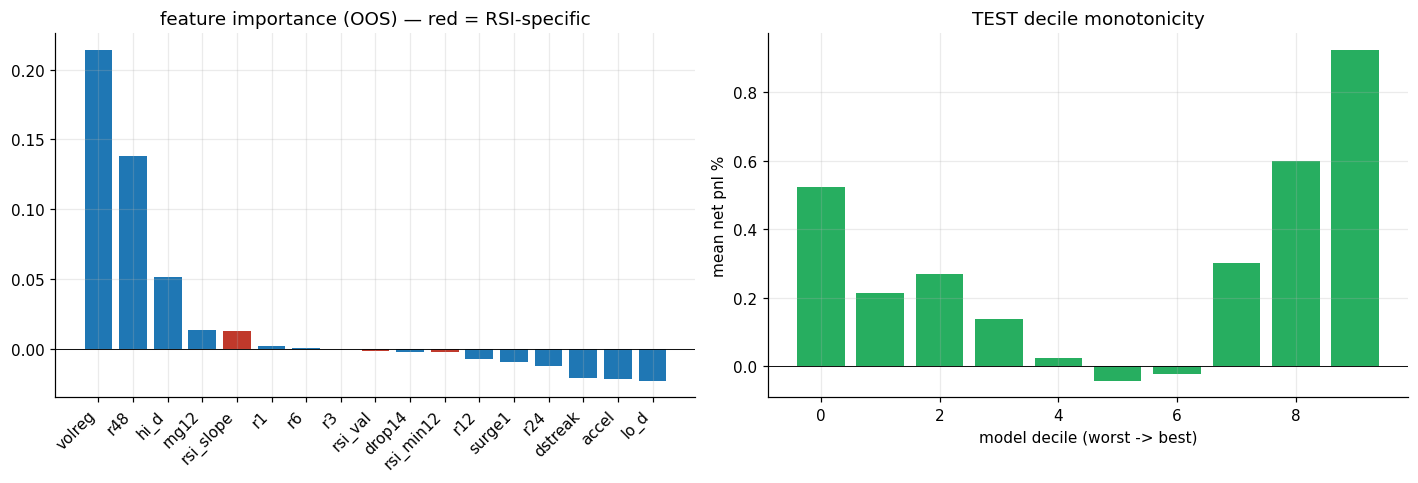

In [5]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(m, te[FULL], te.pnl, n_repeats=8, random_state=0, scoring="r2")
imp = pd.Series(pi.importances_mean, index=FULL).sort_values(ascending=False)
print("=== permutation importance (test, drop in R^2) — RSI features marked * ===")
for k, val in imp.items():
    print(f"  {k:9} {val:+.4f}  {'*' if k in RSIF else ''}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
cols = ["#c0392b" if k in RSIF else "#1f77b4" for k in imp.index]
ax[0].bar(range(len(imp)), imp.values, color=cols); ax[0].set_xticks(range(len(imp)))
ax[0].set_xticklabels(imp.index, rotation=45, ha="right"); ax[0].axhline(0, color="k", lw=.6)
ax[0].set_title("feature importance (OOS) — red = RSI-specific")
ax[1].bar(g.index, g.mean_pnl*100, color="#27ae60"); ax[1].axhline(0, color="k", lw=.6)
ax[1].set_xlabel("model decile (worst -> best)"); ax[1].set_ylabel("mean net pnl %")
ax[1].set_title("TEST decile monotonicity")
show("05_rsi_classifier")

## Verdict & caveats

**Two findings — both point the same way as nb03.**

**1. RSI features add nothing.** OOS corr: magnitude-only **−0.013** vs magnitude+RSI **+0.000** (Δ +0.014 = noise). Permutation importance is dominated by `volreg` (0.21), `r48` (0.14), `hi_d` (0.05) — volatility/regime + trailing return + distance-from-high = **magnitude**. The three RSI-specific features (`rsi_val`, `rsi_slope`, `rsi_min12`) sit at ~0 / bottom. A nonlinear model given RSI for free ignores it — exactly nb03's verdict, now confirmed by a GBM.

**2. The pump/dump classifier technique does NOT transfer cleanly to RSI signals.** Unlike dump (OOS corr +0.117, **monotone** deciles) and pump (+0.30), here **OOS corr ≈ 0 and the decile curve is U-shaped, not monotone** (dec0 +0.53%, dec5–6 ≈0, dec9 +0.93%). The model gets the top right but the bottom wrong → the ranking does not generalize. The apparent filter lift (`pred>0`: +0.68% vs trade-all +0.29%, m/std 0.114→0.21) rides on the top deciles being genuinely good in a favorable Sep–Dec 2024 window, **not** on a robust monotone ranking — so on a single split it is not trustworthy.

**Why weaker than dump:** the dump trigger (−7%/15m) pre-selects a small population of deep dumps with real outcome dispersion the model can separate. The RSI<30 cross fires on a huge mushy population (73k, mostly shallow/sideways dips) with little separable structure — the GBM cannot rank mush, and what little it finds is volatility-regime, not RSI.

**Net:** filtering RSI signals with a classifier doesn't open new edge. The only structure is magnitude/vol-regime (already owned by `dump`), RSI itself is dead weight, and the lift isn't even monotone OOS.

**Caveats:** single 60/40 split (the honest stress is walk-forward, à la dump-14 / the test that killed levels-09 — the U-shape predicts it won't survive); H=4h label only; test window (Q4-2024) was a favorable dip-buy regime (trade-all already +0.29%); 2025 stays sealed; model not saved (not a keeper).